In [1]:
from ml.dataset import get_dataloaders
from ml.models import Conv1Layer, Conv2Layer, Conv3Layer, Conv4Layer, Conv5Layer
from ml.train import Experiment
%load_ext autoreload
%autoreload 2

import logging
import torch
import torch.optim as optim
from torch import nn
from train import Trainer
from visualization import plot_results
import gc

logger = logging.getLogger("Main")
logging.basicConfig(
    filename="logger.log",
    filemode="w",
    level=logging.INFO,
)

In [2]:
torch.manual_seed(42)
torch.use_deterministic_algorithms(True)

if torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

train_loader, val_loader, test_loader = get_dataloaders()

In [3]:
def run_experiment(
        model: nn.Module,
        model_name: str,
        lr: float = 0.001,
        max_epochs: int = 20,
        patience: int = 5,
) -> tuple[float, float, Trainer]:

    loss_fn  = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr = lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, "min", patience=2)

    trainer = Trainer(
        model = model,
        model_name = model_name,
        loss_fn = loss_fn,
        optimizer = optimizer,
        train_loader = train_loader,
        val_loader = val_loader,
        device = device,
        logger=logger,
        scheduler = scheduler,
    )

    val_loss, val_acc = trainer.train_and_validate(max_epochs = max_epochs, patience = patience)

    return val_loss, val_acc, trainer

In [4]:
def run_experiments(exps: list[Experiment], visualize = False):
    for exp in exps:
        model = exp.model_cls(**exp.kwargs)

        val_loss, val_acc, trainer = run_experiment(model = model, model_name = exp.model_name)
        print(f"{exp.model_name}: validation loss: {val_loss:.4f}, validation accuracy: {val_acc:.4f}")

        if visualize:
            plot_results(progress = trainer.progress, model_name = exp.model_name)
        exp.progress = trainer.progress

        del model
        del trainer
        gc.collect()
        if torch.mps.is_available():
            torch.mps.empty_cache()


Conv1_32: validation loss: 2.3080, validation accuracy: 0.5723


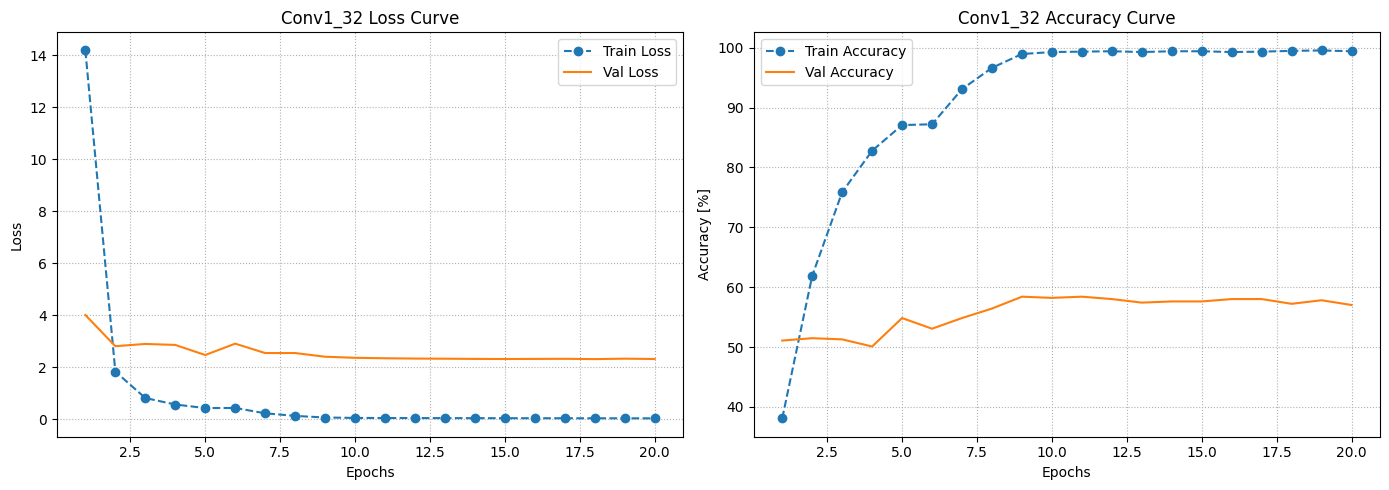

Conv1_64: validation loss: 3.1232, validation accuracy: 0.5723


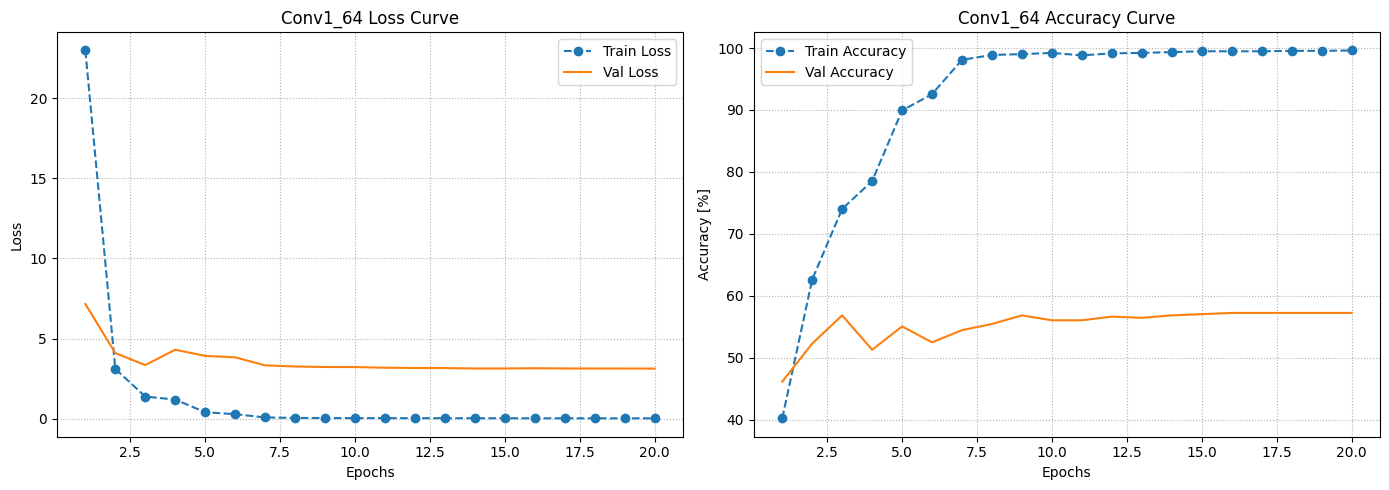

In [5]:
# this structure is created so that the initialization is made
# lazily so it doesn't consume RAM unnecesarily
all_experiments = []
experiments = [
    Experiment("Conv1_32", Conv1Layer, {"n1" : 32}),
    Experiment("Conv1_64", Conv1Layer, {"n1" : 64}),
]

run_experiments(experiments, True)
all_experiments.extend(experiments)

Conv2_16_32: validation loss: 1.1441, validation accuracy: 0.6079


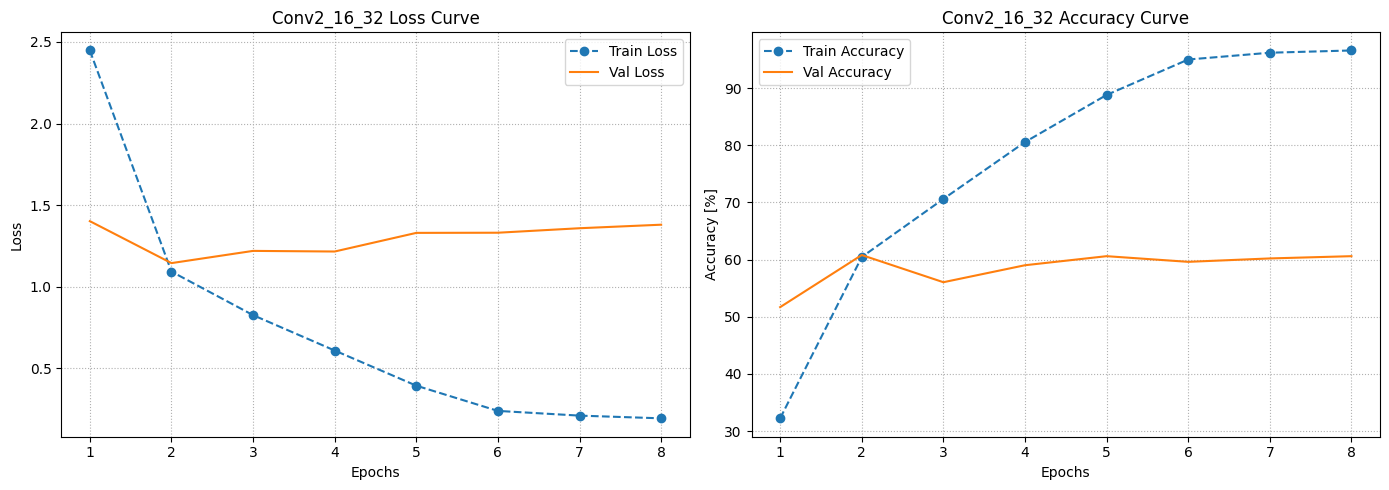

Conv2_32_64: validation loss: 1.1774, validation accuracy: 0.5703


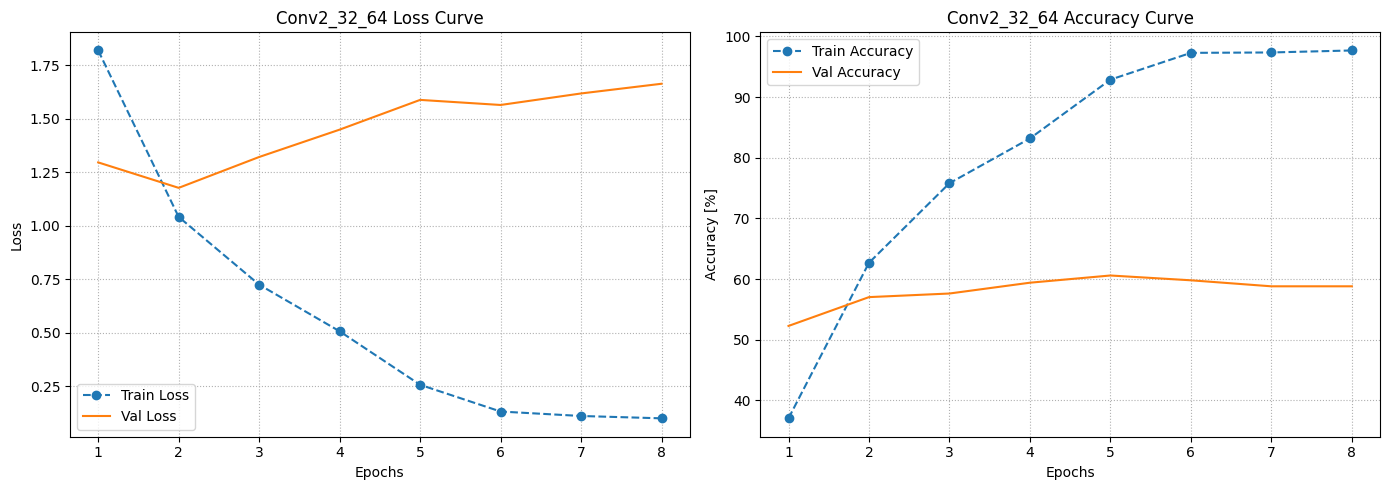

Conv2_32_32: validation loss: 1.2594, validation accuracy: 0.5723


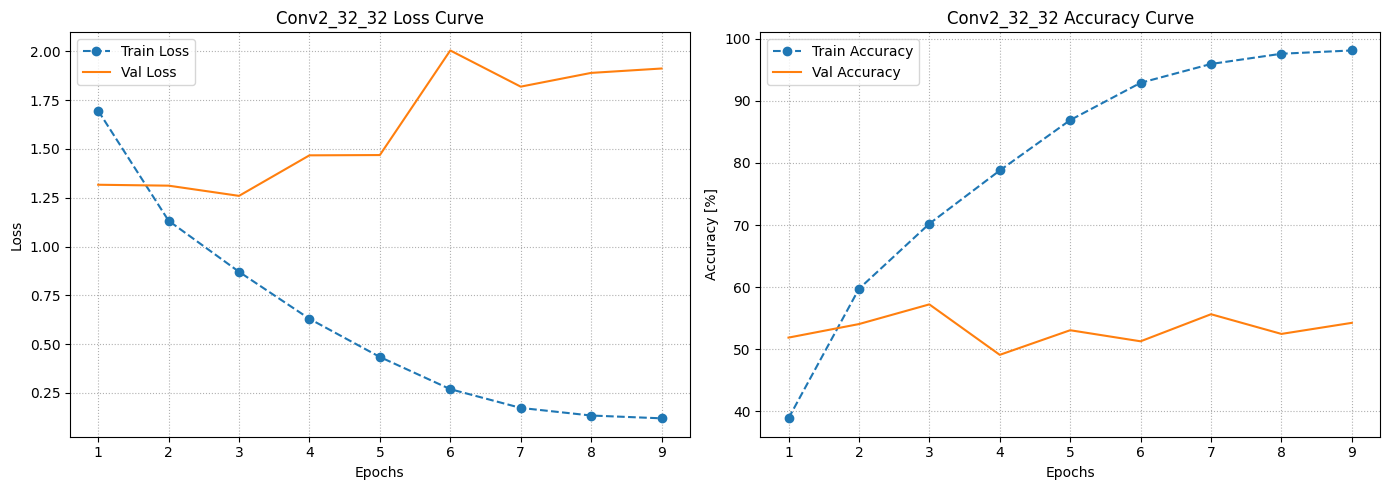

In [8]:
experiments2 = [
    Experiment("Conv2_16_32", Conv2Layer, {"n1" : 16, "n2" : 32}),
    Experiment("Conv2_32_64", Conv2Layer, {"n1" : 32, "n2" : 64}),
    Experiment("Conv2_32_32", Conv2Layer, {"n1" : 32, "n2" : 32}),
]
run_experiments(experiments2, True)
all_experiments.extend(experiments2)

Conv3_16_32_64: validation loss: 1.1467, validation accuracy: 0.6257


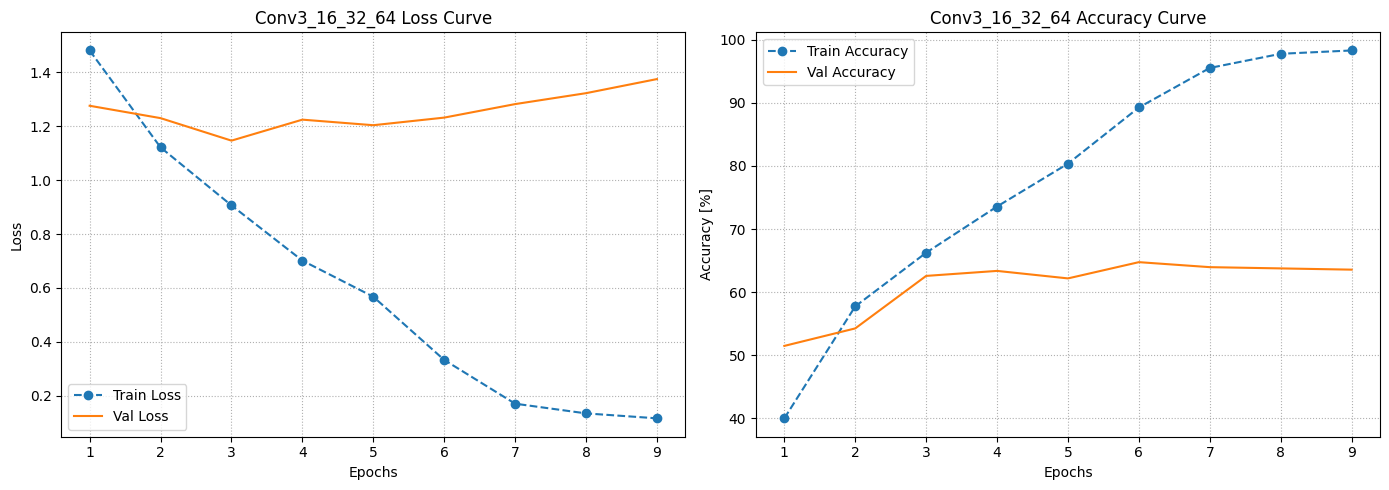

Conv3_32_64_128: validation loss: 1.1406, validation accuracy: 0.6198


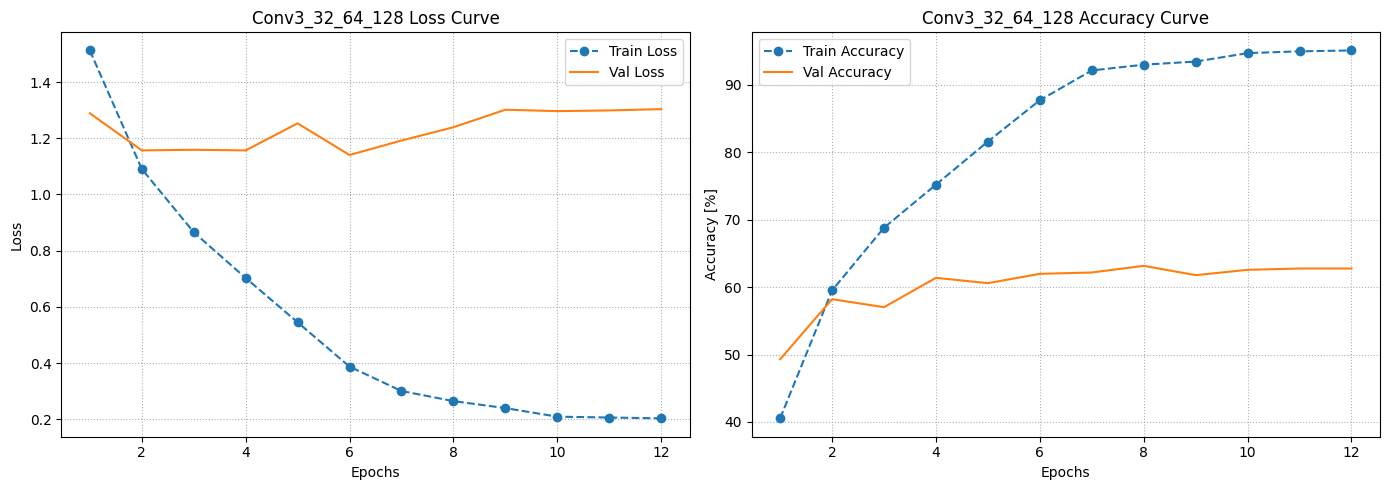

In [9]:
experiments3 = [
    Experiment("Conv3_16_32_64", Conv3Layer, {"n1" : 16, "n2" : 32,"n3" : 64}),
    Experiment("Conv3_32_64_128", Conv3Layer, {"n1" : 32, "n2" : 64, "n3" : 128}),
]
run_experiments(experiments3, True)
all_experiments.extend(experiments3)

Conv4_16_32_64_128: validation loss: 1.1090, validation accuracy: 0.6040


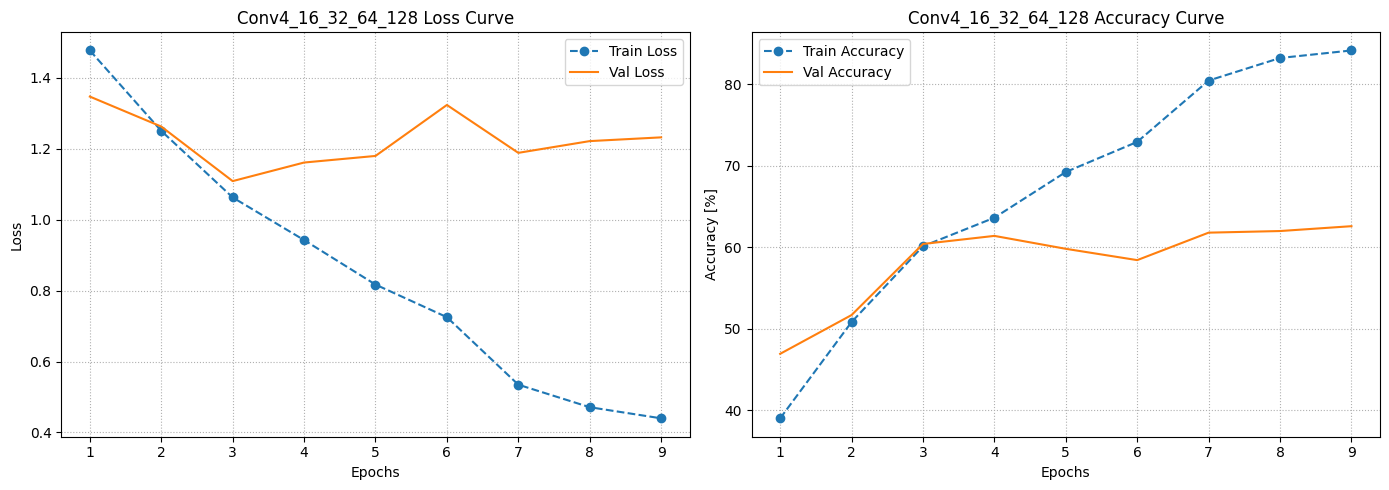

Conv4_32_64_128_256: validation loss: 1.1318, validation accuracy: 0.6178


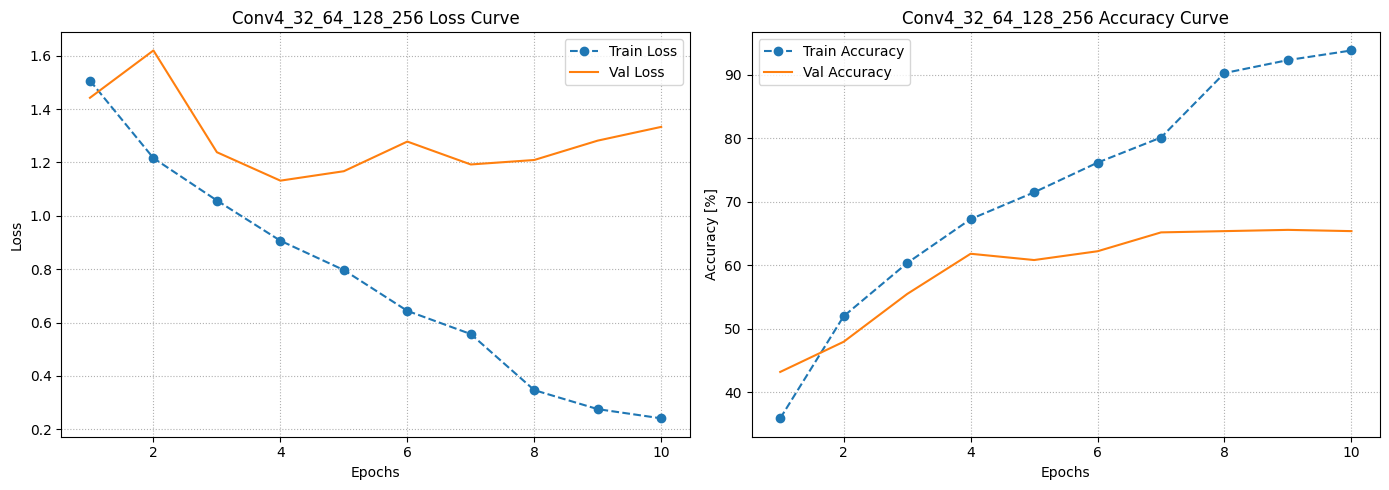

In [10]:
experiments4 = [
    Experiment("Conv4_16_32_64_128", Conv4Layer, {"n1" : 16,"n2" : 32,"n3" : 64, "n4" : 128}),
    Experiment("Conv4_32_64_128_256", Conv4Layer, {"n1" : 32,"n2" : 64, "n3" : 128, "n4" : 256}),
]
run_experiments(experiments4, True)
all_experiments.extend(experiments4)

Conv5_16_32_64_128_256: validation loss: 1.1316, validation accuracy: 0.6119


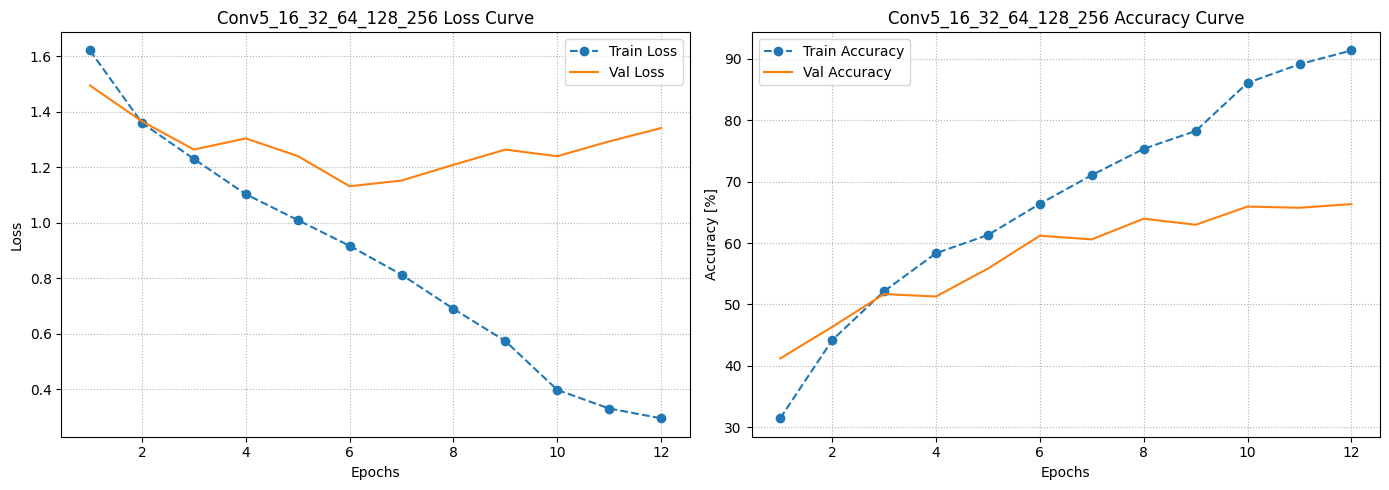

Conv5_32_64_128_256_512: validation loss: 1.0519, validation accuracy: 0.6416


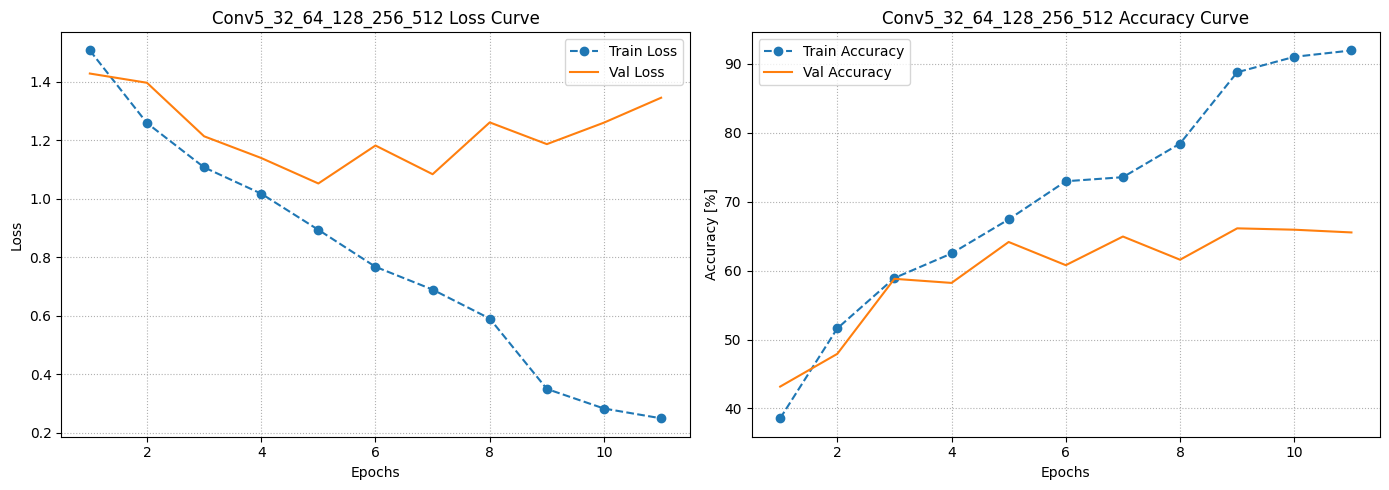

In [11]:
experiments5 = [
    Experiment("Conv5_16_32_64_128_256", Conv5Layer, {"n1" : 16,"n2" : 32,"n3" : 64, "n4" : 128,"n5" : 256}),
    Experiment("Conv5_32_64_128_256_512", Conv5Layer, {"n1" : 32, "n2" : 64, "n3" : 128, "n4" : 256, "n5" : 512}),
]
run_experiments(experiments5, True)
all_experiments.extend(experiments5)